<a href="https://colab.research.google.com/github/TheVxxsh-Sh/Seasonal-Agriculture-Performance-Analysis/blob/main/Seasonal_Agriculture_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset with the exact filename shown in your Colab files panel
df = pd.read_csv('seasonal_agriculture_performance_dataset (3).csv')

# Display the first 5 rows to inspect columns
print("--- First 5 Rows ---")
display(df.head())

# Display general dataset info (data types, non-null counts)
print("\n--- Dataset Info ---")
print(df.info())

--- First 5 Rows ---


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [ ]:
# Check for missing (null) values in each column
print("--- Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Clean/impute missing numerical values with the median of each column
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Verify that no missing values remain
print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum().sum())

--- Missing Values Count ---
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

--- Missing Values After Cleaning ---
0


In [ ]:
# Group by Season to calculate key averages (Yield, Profit, Water Usage, Rainfall)
seasonal_summary = df.groupby('Season')[['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Rainfall_mm']].mean().reset_index()

print("--- Seasonal Performance Summary ---")
print(seasonal_summary.to_string(index=False))

# Calculate overall dataset statistics for profitability
print("\n--- Profitability Statistics (INR) ---")
print(df['Profit_INR'].describe())

--- Seasonal Performance Summary ---
Season  Yield_Tonnes_Ha    Profit_INR  Water_Used_m3  Rainfall_mm
Kharif         5.628612 178914.647555    6102.201237   849.199663
  Rabi         5.039435  87689.470191    5846.987093   437.615366
  Zaid         4.641313 -24804.824916    6419.893939   304.654714

--- Profitability Statistics (INR) ---
count    4.000000e+03
mean     1.115565e+05
std      5.450819e+05
min     -1.019223e+06
25%     -1.487318e+05
50%      3.673000e+03
75%      2.161878e+05
max      4.345421e+06
Name: Profit_INR, dtype: float64


/tmp/ipykernel_483/3053890314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=season_yield, x='Season', y='Yield_Tonnes_Ha', palette='crest')


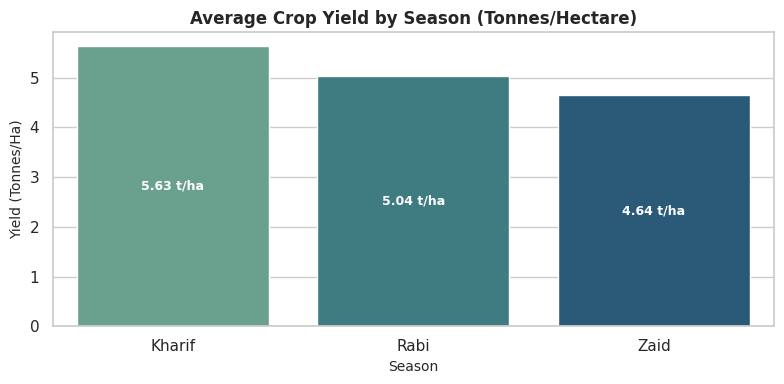

/tmp/ipykernel_483/3053890314.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=season_profit, x='Season', y='Profit_INR', palette='viridis')


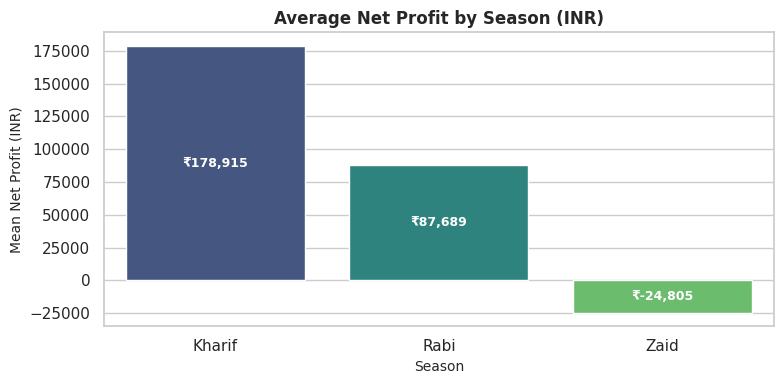

/tmp/ipykernel_483/3053890314.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=season_water, x='Season', y='Water_Used_m3', palette='magma')


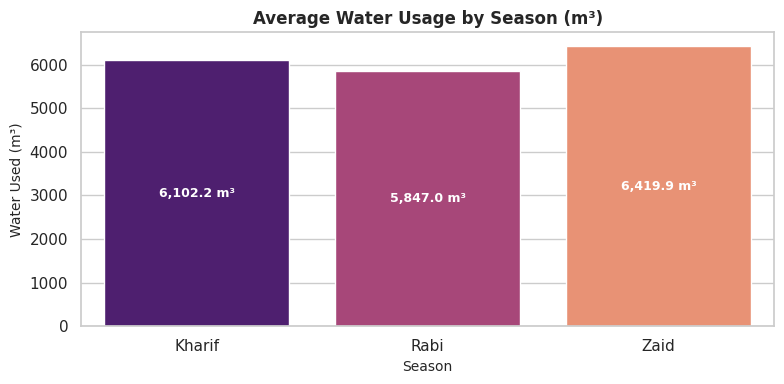

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# 1. Average Crop Yield by Season (For Slide 9)
plt.figure(figsize=(8, 4))
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()
ax = sns.barplot(data=season_yield, x='Season', y='Yield_Tonnes_Ha', palette='crest')
plt.title('Average Crop Yield by Season (Tonnes/Hectare)', fontsize=12, fontweight='bold')
plt.xlabel('Season', fontsize=10)
plt.ylabel('Yield (Tonnes/Ha)', fontsize=10)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f} t/ha", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('yield_by_season.png', dpi=300)
plt.show()

# 2. Average Net Profit by Season (For Slide 7)
plt.figure(figsize=(8, 4))
season_profit = df.groupby('Season')['Profit_INR'].mean().reset_index()
ax = sns.barplot(data=season_profit, x='Season', y='Profit_INR', palette='viridis')
plt.title('Average Net Profit by Season (INR)', fontsize=12, fontweight='bold')
plt.xlabel('Season', fontsize=10)
plt.ylabel('Mean Net Profit (INR)', fontsize=10)
for p in ax.patches:
    ax.annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('profit_by_season.png', dpi=300)
plt.show()

# 3. Average Water Usage by Season (For Slide 8)
plt.figure(figsize=(8, 4))
season_water = df.groupby('Season')['Water_Used_m3'].mean().reset_index()
ax = sns.barplot(data=season_water, x='Season', y='Water_Used_m3', palette='magma')
plt.title('Average Water Usage by Season (m³)', fontsize=12, fontweight='bold')
plt.xlabel('Season', fontsize=10)
plt.ylabel('Water Used (m³)', fontsize=10)
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.1f} m³", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('water_by_season.png', dpi=300)
plt.show()